### 1.0 Installing depedencies

In [ ]:
!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 -q
!pip install sam3 scikit-learn requests ipywidgets -q

### 1.1 Importing Libraries

In [ ]:
from datasets import Dataset, DatasetDict
from collections import defaultdict
from huggingface_hub import login
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

import hashlib
import random
import shutil
import math
import re
import os

### 1.2 Global Definitions

In [ ]:
DATASET_NAME_DIR = '/path/to/dataset/'  # must end with /
TRAINING_DATASET_DIRECTORY = DATASET_NAME_DIR + 'train/'
VALIDATION_DATASET_DIRECTORY = DATASET_NAME_DIR + 'valid/'

### 1.3 Global Settings

In [ ]:
login("TOKEN_HF_WRITE")

### 1.4 Global Structure

In [ ]:
dataset_structure = {
    "path": "",
    "name": "",
    "images": {
        "train": [],
        "val": []
    },
    "labels": {
        "train": [],
        "val": []
    }
}

### 1.5 Global Function Definitions

In [ ]:
def list_files(directory: str, extensions: list, include_root_directory=False, recursive=False):
    matched_files = []

    # Ensure extensions is a tuple for endswith
    ext_tuple = tuple(extensions) if isinstance(extensions, list) else extensions

    if recursive:
        for root, _, files in os.walk(directory):
            for f in files:
                if f.endswith(ext_tuple):
                    matched_files.append(os.path.join(root, f) if include_root_directory else f)
    else:
        for f in os.listdir(directory):
            if f.endswith(ext_tuple) and os.path.isfile(os.path.join(directory, f)):
                matched_files.append(os.path.join(directory, f) if include_root_directory else f)

    return matched_files


def numeric_key(name):
    """Extract the first number from a filename for sorting."""
    nums = re.findall(r'\d+', name)
    return int(nums[0]) if nums else float('inf')


def sort_files_by_number(files: list):
    """
    Sort a list of filenames by the first number found in each name.

    Args:
        files (list): List of filenames (strings)

    Returns:
        list: Sorted list of filenames
    """
    return sorted(files, key=numeric_key)


def update_dataset_structure():
    dataset_structure["path"] = DATASET_NAME_DIR
    dataset_structure["name"] = DATASET_NAME_DIR.split("/")[-2]

    dataset_structure["images"]["train"] = sort_files_by_number(
        list_files(TRAINING_DATASET_DIRECTORY, [".jpg", ".jpeg", ".JPG", ".JPEG"], True)
    )
    dataset_structure["images"]["val"] = sort_files_by_number(
        list_files(VALIDATION_DATASET_DIRECTORY, [".jpg", ".jpeg", ".JPG", ".JPEG"], True)
    )
    dataset_structure["labels"]["train"] = sort_files_by_number(
        list_files(TRAINING_DATASET_DIRECTORY, [".txt"], True)
    )
    dataset_structure["labels"]["val"] = sort_files_by_number(
        list_files(VALIDATION_DATASET_DIRECTORY, [".txt"], True)
    )

def delete_files_in_dataset(files_to_delete: list):
    try:
        confirm = input("Files are going to be deleted. Type 'yes' to continue: ").strip().lower()
        if confirm != 'yes':
            print("Deletion aborted by user.")
            return

        for file in files_to_delete:
            if os.path.isfile(file):
                os.remove(file)
                print(f"Deleted: {file}")
            else:
                print(f"Warning: File does not exist: {file}")

    except KeyboardInterrupt:
        print("\nDeletion aborted by user (KeyboardInterrupt).")
    finally:
        try:
            update_dataset_structure()
        except NameError:
            pass


def backup_dataset():
    dataset_path = dataset_structure.get("path", "")
    backup_dir = os.path.join(dataset_path, "backup")
    os.makedirs(backup_dir, exist_ok=True)

    now = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    target_name = f"{dataset_structure["name"]}-{now}"
    target_path = os.path.join(backup_dir, target_name)

    # Copytree with ignore to exclude the backup folder itself
    def ignore_backup(src, names):
        return {"backup"} if "backup" in names else set()

    shutil.copytree(dataset_path, target_path, ignore=ignore_backup)
    print(f"Backup created at: {target_path}")
    return str(target_path)

# 📂 2. Dataset

### 2.2 Data Structure Check

#### Directory path validation

In [ ]:
update_dataset_structure()

print(f"Dataset path: {dataset_structure['path']}")
print(f"Dataset name: {dataset_structure['name']}\n")

print(f"Number of images : {len(dataset_structure['images']['train']) + len(dataset_structure['images']['val'])}")
print(f"\t- train: {len(dataset_structure['images']['train'])}")
print(f"\t- val: {len(dataset_structure['images']['val'])}")

print(f"Number of labels : {len(dataset_structure['labels']['train']) + len(dataset_structure['labels']['val'])}")
print(f"\t- train: {len(dataset_structure['labels']['train'])}")
print(f"\t- val: {len(dataset_structure['labels']['val'])}")

#### Duplicate files

Check for duplicate images and labels.

In [ ]:
duplicate_paths_to_check = [
    dataset_structure["images"]["train"],
    dataset_structure["images"]["val"],
    dataset_structure["labels"]["train"],
    dataset_structure["labels"]["val"],
]


def sha3_file(path, chunk_size=8192):
    hash_sha3 = hashlib.sha3_256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hash_sha3.update(chunk)
    return hash_sha3.hexdigest()


duplicates_array = []

for path in duplicate_paths_to_check:

    # Build list of (hash, path)
    pairs = [
        (sha3_file(f), f)
        for f in path
    ]

    # Group paths by hash
    hash_map = defaultdict(list)
    for h, p in pairs:
        hash_map[h].append(p)

    # Extract only duplicates
    duplicates = {h: paths for h, paths in hash_map.items() if len(paths) > 1}
    duplicates_array.append(duplicates)

    # Print results
    if duplicates:
        print("Duplicate files found:")
        for h, paths in duplicates.items():
            print(f"Hash: {h}")
            for p in paths:
                print(f"  - {p}")
    else:
        print(f"No duplicate files found in the scanned directories.")


##### ⚠️Delete duplicate files ⚠️

Delete for duplicate images and labels.

In [ ]:
try:
    if input("Files are going to be deleted. Write yes to continue.") == 'yes':
        for duplicates in duplicates_array:
            for paths in duplicates.values():
                for path in paths:
                    os.remove(path)
except KeyboardInterrupt:
    print("Deletion aborted.")
finally:
    update_dataset_structure()

#### Check for orphelins txt file

In [ ]:
orphans_duplicate_paths_to_check = [
    dataset_structure["labels"]["train"],
    dataset_structure["labels"]["val"],
]

orphelins_label = []

for path_list in orphans_duplicate_paths_to_check:
    for p in path_list:

        root, _ = os.path.splitext(p)
        root = root.replace("/labels/", "/images/")

        candidates = [
            root + ".jpg",
            root + ".JPG",
            root + ".jpeg",
            root + ".JPEG",
            root + ".png",
            root + ".PNG",
        ]

        if not any(os.path.isfile(c) for c in candidates):
            orphelins_label.append(p)
            print(f"TXT file {p} does not belong to any image.")
print("Done")

##### ⚠️Delete orphelin labels files ⚠️

Delete labels that don't belong to any images.

In [ ]:
delete_files_in_dataset(orphelins_label)

#### Rename files

Rename images and labels from 0 to n images.

In [ ]:
TRAIN = TRAINING_DATASET_DIRECTORY
VAL = VALIDATION_DATASET_DIRECTORY

jpeg_exts = [".jpg", ".jpeg", ".JPG", ".JPEG"]

tmp = os.path.join(DATASET_NAME_DIR, "tmp")


def numeric_key(name):
    nums = re.findall(r'\d+', name)
    return int(nums[0]) if nums else float('inf')


def collect_images(folder):
    return sorted(
        [f for f in os.listdir(folder) if f.endswith(tuple(jpeg_exts))],
        key=numeric_key
    )


def process(folder, start_i, out_dir):
    files = collect_images(folder)
    print(f"Processing {out_dir}...")

    if not os.path.exists(out_dir):
        os.mkdir(out_dir)

    for f in files:
        pass
        root, ext = os.path.splitext(f)

        # find real existing image
        image_path = None
        for e in jpeg_exts:
            p = os.path.join(folder, root + e)
            if os.path.isfile(p):
                image_path = p
                break

        if image_path is None:
            print("Missing image for:", f)
            continue

        label_path = os.path.join(folder, root + ".txt")
        if not os.path.isfile(label_path):
            os.rename(image_path, os.path.join(out_dir, f"{start_i}.jpg"))
            start_i += 1
            continue

        new_image = os.path.join(out_dir, f"{start_i}.jpg")
        new_label = os.path.join(out_dir, f"{start_i}.txt")

        # Move safely
        os.rename(image_path, new_image)
        os.rename(label_path, new_label)

        start_i += 1

    os.rmdir(folder)
    os.rename(out_dir, folder)

    return start_i


# === RUN ===
backup_dataset()

i = 0
i = process(TRAIN, i, tmp + '_training')
i = process(VAL, i, tmp + '_valid')

update_dataset_structure()

print(f"DONE — All files renamed safely into {DATASET_NAME_DIR}tmp_NAME")

### Set labels

In [ ]:
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import plot_results
from sam3 import build_sam3_image_model

In [ ]:
bpe_name = "bpe_simple_vocab_16e6.txt.gz"

##### Load model

In [ ]:
model = build_sam3_image_model(bpe_path=os.path.join(MODELS_DIRECTORY, bpe_name))
processor = Sam3Processor(model)

In [ ]:
image_path = f"datasets/new_dataset/training/633.jpg"
prompt = "drone"
confidence_threshold = 0.5

image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=confidence_threshold)
inference_state = processor.set_image(image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt=prompt)
img0 = Image.open(image_path)
plot_results(img0, inference_state)

##### Settings

In [ ]:
labelize_overwrite_label: bool = True
labelize_prompt: str = 'drone'
labelize_confidence_threshold: float = 0.62
labelize_drone_class = 0
labelize_output_label_file_directory = os.path.join(DATASET_NAME_DIR, 'new_labels')
labelize_output_label_file_errors = os.path.join(labelize_output_label_file_directory, 'errors.txt')
labelize_output_label_file_success = os.path.join(labelize_output_label_file_directory, 'success.txt')

liberalizations_path = [
    dataset_structure["train_files_images"],
    dataset_structure["valid_files_images"],
]


In [ ]:
os.makedirs(labelize_output_label_file_directory, exist_ok=True)

image_failed_labelize = []

for paths in liberalizations_path:
    for image_path in paths:
        root, ext = os.path.splitext(image_path)
        root_label_name = root.split("/")[-1]
        current_label_path = root + ".txt"
        saved_label_path = os.path.join(labelize_output_label_file_directory, root_label_name) + ".txt"

        if os.path.isfile(current_label_path) and not labelize_overwrite_label:
            continue

        if os.path.isfile(saved_label_path) and not labelize_overwrite_label:
            continue

        # Load image
        image = Image.open(image_path)
        if image.mode != "RGB":
            with open(labelize_output_label_file_errors, "a") as f:
                image_failed_labelize.append(image_path)
                f.write(f"{image_path} is not RGB.\n")
            continue
        width, height = image.size

        # Run SAM3 processor
        processor = Sam3Processor(model, confidence_threshold=labelize_confidence_threshold)
        inference_state = processor.set_image(image)
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=labelize_prompt)

        # --- Save YOLO labels ---
        bboxes = inference_state.get("boxes", None)  # fixed

        if bboxes is None or len(bboxes) == 0:
            # print(f"No detections for {image_path}")
            image_failed_labelize.append(image_path)
            with open(labelize_output_label_file_errors, "a") as f:
                f.write(f"No detections for {image_path}\n")
            continue

        yolo_lines = []
        for box in bboxes:
            x_min, y_min, x_max, y_max = box  # SAM3 gives XYXY

            # Convert to YOLO format
            bbox_width = x_max - x_min
            bbox_height = y_max - y_min

            cx = (x_min + bbox_width / 2) / width
            cy = (y_min + bbox_height / 2) / height

            nw = bbox_width / width
            nh = bbox_height / height

            yolo_lines.append(
                f"{labelize_drone_class} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
            )

        with open(saved_label_path, "w") as f:
            f.write("\n".join(yolo_lines))
        with open(labelize_output_label_file_success, "a") as f:
            f.write(f"Saved YOLO labels: {saved_label_path}\n")

    with open(labelize_output_label_file_success, 'r') as fp:
        nb_lines = len(fp.readlines())
        print(f"Successfully procedded files: {nb_lines} out of {len(paths)}")

In [ ]:
try:
    if input("Files are going to be deleted. Write yes to continue.") == 'yes':
        for image_path in image_failed_labelize:
            os.remove(image_path)
except KeyboardInterrupt:
    print("Deletion aborted.")

### 2.3 Check

Load N random images and show rectangles around the drones detected by SAM3.

In [35]:
def load_image_with_boxes(image_path, label_path):
    """Returns a PIL image with YOLO bounding boxes drawn."""
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    w, h = img.size

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            cls, xc, yc, bw, bh = map(float, line.split())

            # YOLO normalized → pixel coordinates
            x_center = xc * w
            y_center = yc * h
            box_width = bw * w
            box_height = bh * h

            x1 = x_center - box_width / 2
            y1 = y_center - box_height / 2
            x2 = x_center + box_width / 2
            y2 = y_center + box_height / 2

            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, y1), f"{int(cls)}", fill="red")

    return img

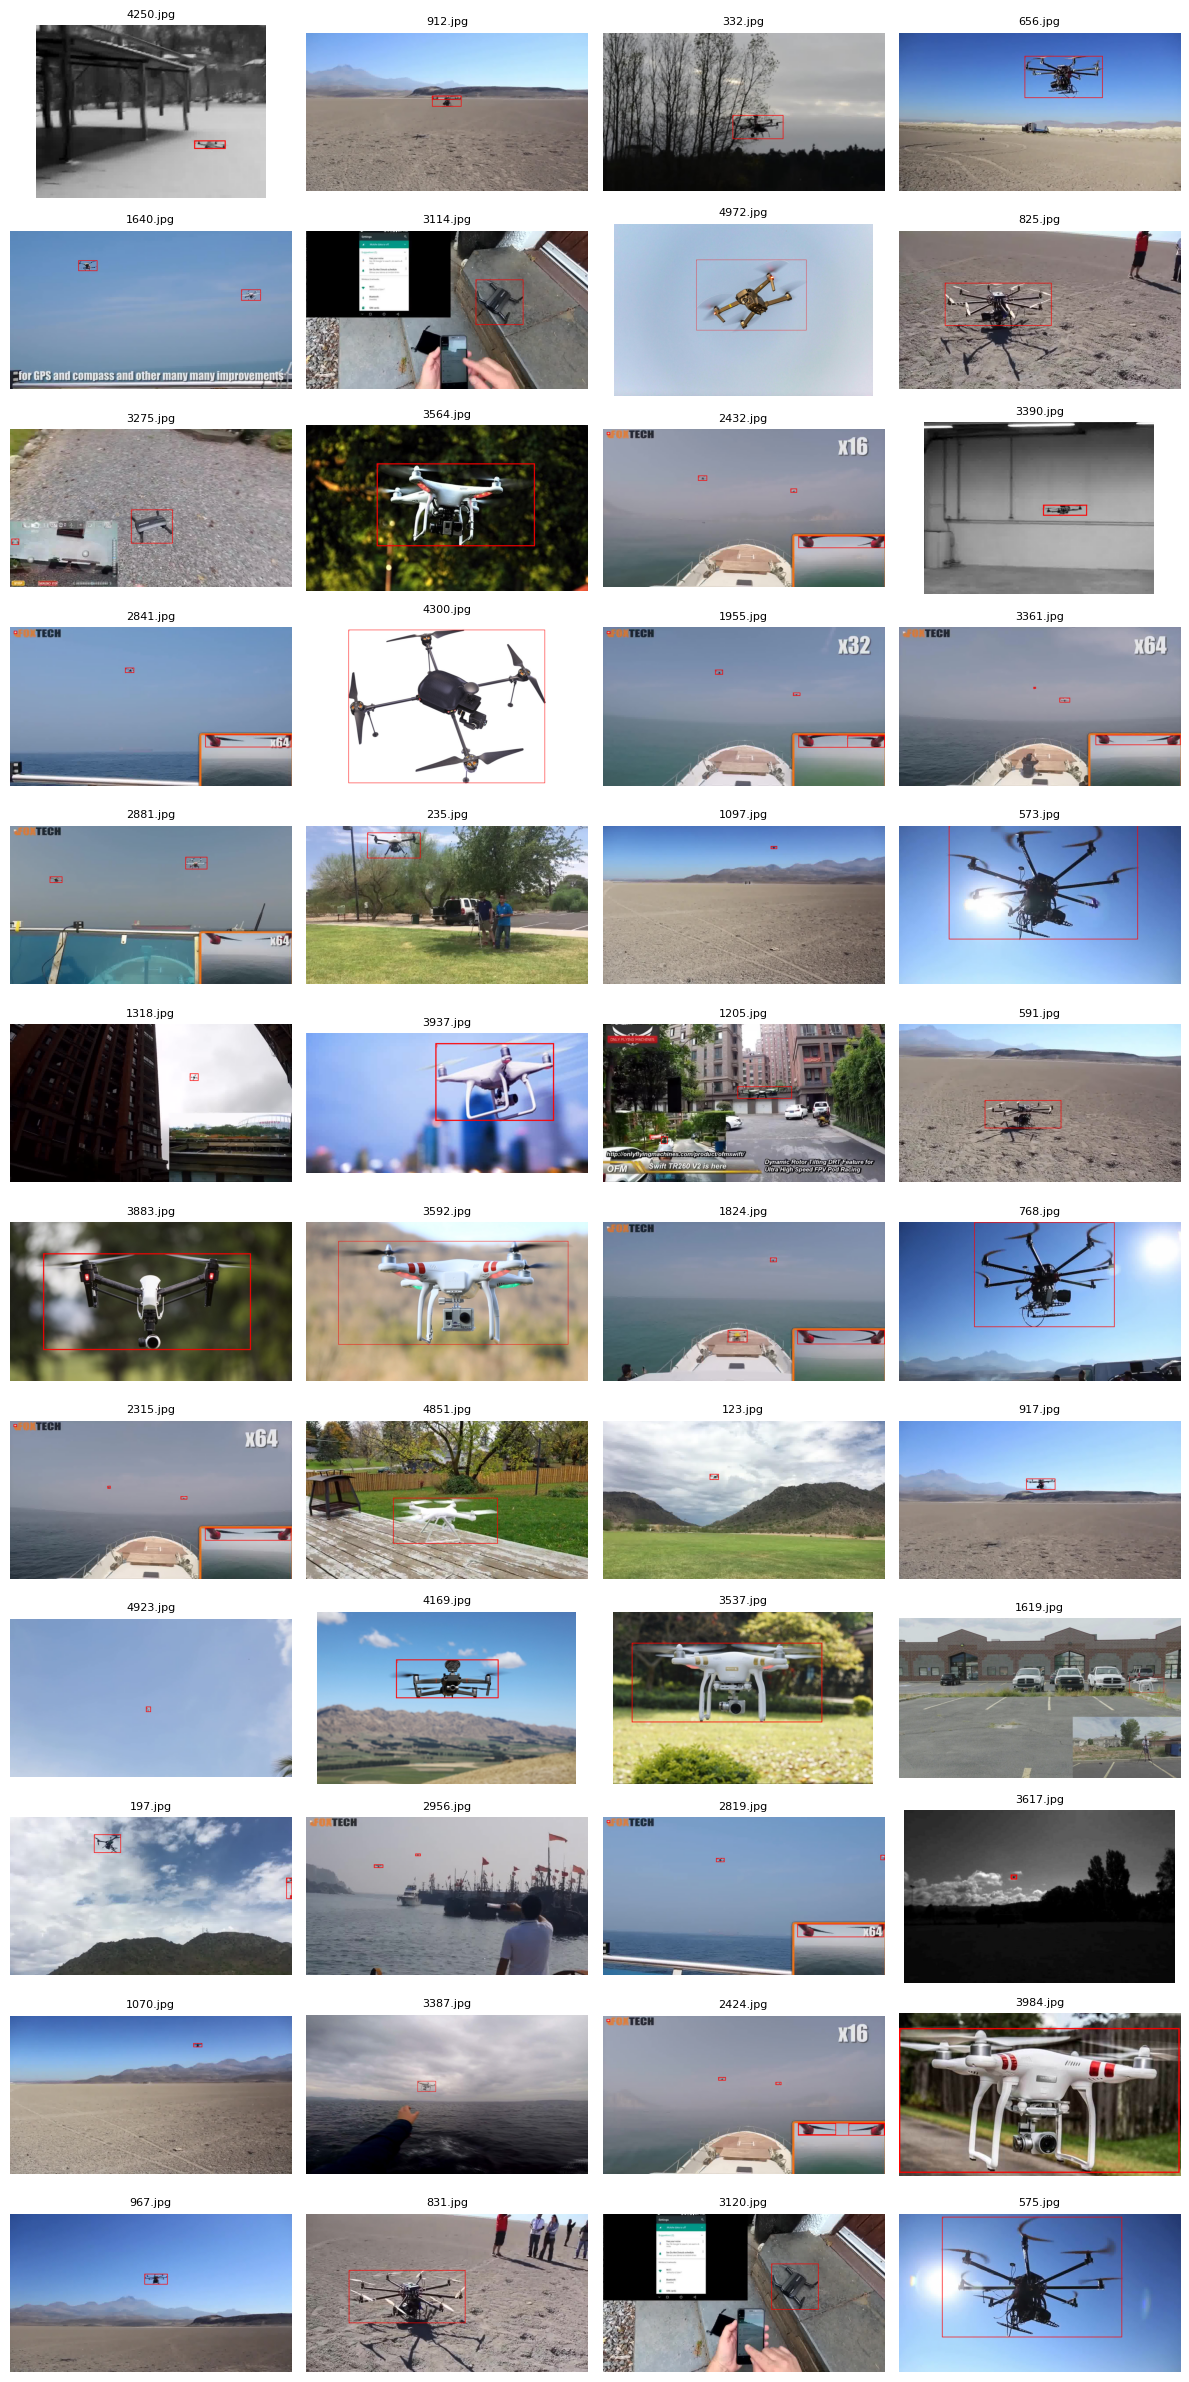

In [36]:
N = 48  # number of random samples
cols = 4

%matplotlib inline

# list all images
image_paths = [p for p in os.listdir(TRAINING_DATASET_DIRECTORY) if p.lower().endswith((".jpg", ".png"))]
sampled_images = random.sample(image_paths, min(N, len(image_paths)))

# -------- DISPLAY GRID -------- #

rows = math.ceil(len(sampled_images) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 2))
axes = axes.flatten()

for ax, img_name in zip(axes, sampled_images):
    img_path = os.path.join(TRAINING_DATASET_DIRECTORY, img_name)
    label_path = os.path.join(TRAINING_DATASET_DIRECTORY, img_name.rsplit(".", 1)[0] + ".txt")

    img = load_image_with_boxes(img_path, label_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_name, fontsize=8)

# turn off unused axes
for ax in axes[len(sampled_images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

#### Upload

In [ ]:
def load_split(image_dir: Path, label_dir: Path):
    data = []
    for img_path in image_dir.glob("*.jpg"):
        label_path = label_dir / f"{img_path.stem}.txt"
        with open(label_path) as f:
            label = str(f.read().strip())  # parse label as needed
        data.append({"image": Image.open(img_path), "label": label})
    return Dataset.from_list(data)

# Paths
train_image_dir = Path("/home/adrien/Downloads/dataset/train")
train_label_dir = Path("/home/adrien/Downloads/dataset/train")

val_image_dir = Path("/home/adrien/Downloads/dataset/valid")
val_label_dir = Path("/home/adrien/Downloads/dataset/valid")

# Load datasets
train_dataset = load_split(train_image_dir, train_label_dir)
val_dataset = load_split(val_image_dir, val_label_dir)

print(train_dataset)

# Combine into DatasetDict
dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})
#
print(dataset)
print(dataset["train"][0])
print(dataset["validation"][0])


In [ ]:
dataset.push_to_hub("Hibou-Foundation/computer-vision")